# IRT calibration

Diagnostics for the pooled IRT fit. The three sources of evidence are:
1PL vs 2PL parsimony, leave-one-out stability across calibration models, and external
validation against the native difficulty labels in each domain. All numbers are loaded
live from the shipped parquets.

In [1]:
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 120,
})

DATA = Path('data/processed')
OUT_FIGS = Path('figures')
OUT_FIGS.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ['code', 'math', 'sat']
DOMAIN_LABEL = {'code': 'Code', 'math': 'Math', 'sat': 'SAT'}
PAPER_LABEL = {
    'deepseek-r1-7b': 'DS-R1-7B', 'deepseek-r1-14b': 'DS-R1-14B',
    'deepseek-r1-32b': 'DS-R1-32B', 'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'R1-Llama-8B', 'phi-4-reasoning': 'Phi-4-R',
    'qwen-7b': 'Qwen-7B', 'qwen-14b': 'Qwen-14B', 'qwen-32b': 'Qwen-32B',
    'llama-8b': 'Llama-8B', 'phi-4': 'Phi-4',
}
REASONING_ORDER = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'qwq-32b', 'r1-distill-llama-8b', 'phi-4-reasoning']
BASELINE_ORDER = ['qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
MODEL_ORDER = REASONING_ORDER + BASELINE_ORDER
PAPER_LABELS = [PAPER_LABEL[m] for m in MODEL_ORDER]


## Generate analysis inputs

When `IRT_RESULTS_ROOT` points at a populated `data/results/` tree (after
running `scripts/run_*.py` against the HuggingFace dataset), the cells
below regenerate the parquets under `data/processed/`. Otherwise they
fall back to the shipped cache.


In [2]:
# >>> generation-marker <<<
RESULTS = Path(os.environ.get('IRT_RESULTS_ROOT', 'data/results'))
PROCESSED = Path('data/processed')
REGEN = RESULTS.exists() and any(RESULTS.rglob('cot_analysis/cot_analysis.parquet'))
print(f'regenerate from raw? {REGEN}  (IRT_RESULTS_ROOT={RESULTS})')


regenerate from raw? False  (IRT_RESULTS_ROOT=data/results)


### Build response matrices from per-model cot_analysis


In [3]:
# Build IRT response matrices from per-model cot_analysis.parquet (32 models x 3 domains)
ALL_32 = [
    'deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
    'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning',
    'qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4',
    'gemma-9b', 'phi-3.5', 'mistral-7b', 'qwen-math-7b',
    'deepseek-7b-chat', 'olmo-7b', 'qwen2-7b', 'zephyr-7b',
    'claude-haiku-4.5', 'claude-sonnet-4', 'deepseek-v3',
    'gemini-2.5-flash', 'gemini-2.5-flash-lite', 'gemini-2.5-pro',
    'gemma-3-27b', 'gpt-4o', 'gpt-4o-mini', 'llama-3.3-70b',
    'mistral-small-24b', 'o4-mini', 'qwen-2.5-72b',
]

if REGEN:
    for dom in DOMAIN_ORDER:
        rows = []
        for model in ALL_32:
            p = RESULTS / dom / model / 'cot_analysis' / 'cot_analysis.parquet'
            if not p.exists():
                continue
            df = pd.read_parquet(p, columns=['problem_id', 'correct'])
            agg = (df.assign(correct=df['correct'].astype(int))
                     .groupby('problem_id', as_index=False)
                     .agg(n_correct=('correct', 'sum'), n_total=('correct', 'count')))
            agg.insert(0, 'model_id', model)
            rows.append(agg.rename(columns={'problem_id': 'item_id'}))
        out = pd.concat(rows, ignore_index=True)
        out.to_parquet(f'data/calibration/responses_{dom}.parquet', index=False)
        print(f'  wrote responses_{dom}.parquet: {len(out):,} rows, {out.model_id.nunique()} models')
else:
    print('using shipped data/calibration/responses_*.parquet')


using shipped data/calibration/responses_*.parquet


### Fit pooled IRT (1PL) per domain


In [4]:
# Fit pooled IRT (Rasch 1PL) per domain -> 01_difficulties.parquet
import torch
from src.irt import fit_irt_model

if REGEN:
    parts = []
    for dom in DOMAIN_ORDER:
        torch.manual_seed(42)
        resp = pd.read_parquet(f'data/calibration/responses_{dom}.parquet')
        res = fit_irt_model(resp, num_epochs=2000, verbose=False)
        parts.append(pd.DataFrame({
            'item_id': [f'{dom}_{i}' for i in res['item_ids']],
            'difficulty': res['diff'],
            'discrimination': 1.0,
        }))
    pd.concat(parts).to_parquet(PROCESSED / '01_difficulties.parquet', index=False)
    print(f'refit IRT for {len(DOMAIN_ORDER)} domains -> 01_difficulties.parquet')
else:
    print('using shipped 01_difficulties.parquet')


using shipped 01_difficulties.parquet


### Boundary classification


In [5]:
# Classify items as floor / ceiling / informative; write 01_boundary_items.parquet
if REGEN:
    diffs = pd.read_parquet(PROCESSED / '01_difficulties.parquet')
    parts = []
    for dom in DOMAIN_ORDER:
        resp = pd.read_parquet(f'data/calibration/responses_{dom}.parquet')
        agg = (resp.groupby('item_id', as_index=False)
                     .agg(n_correct=('n_correct', 'sum'), n_total=('n_total', 'sum')))
        agg['pass_rate'] = agg['n_correct'] / agg['n_total']
        agg['status'] = 'informative'
        agg.loc[agg['n_correct'] == 0, 'status'] = 'floor'
        agg.loc[agg['n_correct'] == agg['n_total'], 'status'] = 'ceiling'
        d_lookup = diffs.set_index('item_id')['difficulty']
        agg['difficulty'] = agg['item_id'].map(lambda x: d_lookup.get(f'{dom}_{x}', float('nan')))
        agg.insert(0, 'domain', dom)
        parts.append(agg)
    pd.concat(parts).to_parquet(PROCESSED / '01_boundary_items.parquet', index=False)
    print('rebuilt 01_boundary_items.parquet')
else:
    print('using shipped 01_boundary_items.parquet')


using shipped 01_boundary_items.parquet


### External validation summary


In [6]:
# Compute the IRT validation summary (01_irt_summary.parquet) from shipped data:
# external validation, 1PL-vs-2PL agreement, and leave-one-model-out stability.
# Recomputed every run from data/calibration/responses_*.parquet and the shipped
# difficulties so the table can never go stale; nothing here is hard-coded.
import torch
from scipy.stats import spearmanr, pearsonr, kruskal
from src.irt import fit_irt_model

diffs = pd.read_parquet(PROCESSED / '01_difficulties.parquet').copy()
diffs[['domain', 'item_id_stripped']] = diffs['item_id'].str.split('_', n=1, expand=True)
ds = Path('data/datasets')
DATASET = {
    'code': (pd.read_parquet(ds / 'selected_500.parquet').set_index('join_key'), 'unnorm_rating'),
    'math': (pd.read_parquet(ds / 'selected_500_math.parquet').set_index('join_key'), 'level_int'),
    'sat':  (pd.read_parquet(ds / 'selected_500_sat.parquet').set_index('join_key'), 'num_clauses'),
}

rows = []
for dom in DOMAIN_ORDER:
    df_ds, native_col = DATASET[dom]
    resp = pd.read_parquet(f'data/calibration/responses_{dom}.parquet')

    # external validation: shipped difficulty vs withheld native label
    sub = diffs[diffs['domain'] == dom].set_index('item_id_stripped')['difficulty']
    m = df_ds.join(sub, how='inner').dropna(subset=[native_col, 'difficulty'])
    x = m[native_col].astype(float).values
    y = m['difficulty'].astype(float).values
    rho = float(spearmanr(x, y)[0])
    if dom == 'math':
        note = f'Kruskal-Wallis H={kruskal(*[m[m["level_int"] == L]["difficulty"].values for L in range(1, 6)])[0]:.2f}'
    else:
        note = f'Pearson r={pearsonr(x, y)[0]:.3f}'
    rows.append({'metric': 'external_validation', 'domain': dom,
                 'value': rho, 'lo': None, 'hi': None, 'n': int(len(m)), 'note': note})

    # 1PL vs 2PL difficulty agreement (2PL fit for validation only)
    torch.manual_seed(42); f1 = fit_irt_model(resp, model_type='1pl', num_epochs=2000, verbose=False)
    torch.manual_seed(42); f2 = fit_irt_model(resp, model_type='2pl', num_epochs=2000, verbose=False)
    d1 = pd.Series(f1['diff'], index=[str(i) for i in f1['item_ids']])
    d2 = pd.Series(f2['diff'], index=[str(i) for i in f2['item_ids']])
    j = pd.concat([d1, d2], axis=1, keys=['a', 'b']).dropna()
    rows.append({'metric': '1pl_vs_2pl', 'domain': dom,
                 'value': float(spearmanr(j['a'], j['b'])[0]), 'lo': None, 'hi': None,
                 'n': int(len(j)), 'note': 'Spearman rho(1PL,2PL) item difficulty'})

    # leave-one-model-out recalibration stability
    loo = []
    for mod in sorted(resp['model_id'].unique()):
        torch.manual_seed(42)
        fl = fit_irt_model(resp[resp.model_id != mod], model_type='1pl', num_epochs=1200, verbose=False)
        dl = pd.Series(fl['diff'], index=[str(i) for i in fl['item_ids']])
        jj = pd.concat([d1, dl], axis=1, keys=['a', 'b']).dropna()
        loo.append(spearmanr(jj['a'], jj['b'])[0])
    loo = np.array(loo)
    rows.append({'metric': 'loo_stability', 'domain': dom,
                 'value': float(np.median(loo)), 'lo': float(loo.min()), 'hi': float(loo.max()),
                 'n': int(len(loo)), 'note': 'median/min/max Spearman over leave-one-model-out refits'})
    print(f'  {dom}: ext-val rho={rho:.3f} | 1PL-2PL={rows[-2]["value"]:.4f} | LOO median={rows[-1]["value"]:.4f}')

summary = pd.DataFrame(rows)
summary.to_parquet(PROCESSED / '01_irt_summary.parquet', index=False)
print(f'wrote 01_irt_summary.parquet ({len(summary)} rows: external_validation, 1pl_vs_2pl, loo_stability)')

  code: ext-val rho=0.552 | 1PL-2PL=0.9892 | LOO median=0.9996


  math: ext-val rho=0.424 | 1PL-2PL=0.9656 | LOO median=0.9995


  sat: ext-val rho=0.559 | 1PL-2PL=0.9413 | LOO median=0.9949
wrote 01_irt_summary.parquet (9 rows: external_validation, 1pl_vs_2pl, loo_stability)


---


## External validation, 1PL vs 2PL, and leave-one-out stability

In [7]:
df_summary = pd.read_parquet(DATA / '01_irt_summary.parquet')
for metric in sorted(df_summary['metric'].unique()):
    sub = df_summary[df_summary['metric'] == metric][['domain', 'value', 'lo', 'hi', 'n', 'note']]
    print(f'-- {metric} --')
    print(sub.to_string(index=False))
    print()


-- 1pl_vs_2pl --
domain    value  lo  hi   n                                  note
  code 0.989160 NaN NaN 500 Spearman rho(1PL,2PL) item difficulty
  math 0.965616 NaN NaN 500 Spearman rho(1PL,2PL) item difficulty
   sat 0.941319 NaN NaN 500 Spearman rho(1PL,2PL) item difficulty

-- external_validation --
domain    value  lo  hi   n                   note
  code 0.551917 NaN NaN 500        Pearson r=0.518
  math 0.424099 NaN NaN 500 Kruskal-Wallis H=95.56
   sat 0.559296 NaN NaN 500        Pearson r=0.589

-- loo_stability --
domain    value       lo       hi  n                                                    note
  code 0.999604 0.990608 0.999964 32 median/min/max Spearman over leave-one-model-out refits
  math 0.999534 0.998165 0.999889 32 median/min/max Spearman over leave-one-model-out refits
   sat 0.994900 0.991529 0.998988 32 median/min/max Spearman over leave-one-model-out refits



## Boundary items figure (`boundary_items.pdf`)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


status  floor  informative
domain                    
code       43          457
math       30          470
sat         0          500


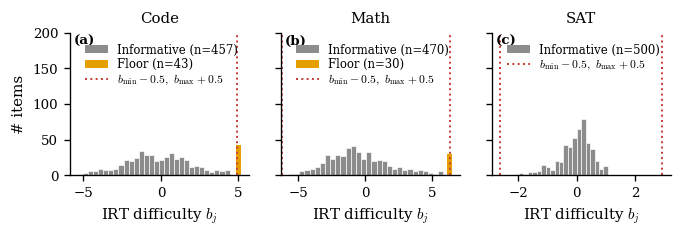

In [8]:
df_b = pd.read_parquet(DATA / '01_boundary_items.parquet')
counts = df_b.groupby(['domain', 'status']).size().unstack(fill_value=0).reindex(index=DOMAIN_ORDER)
print(counts.to_string())

from matplotlib.lines import Line2D
GREY, ORANGE, RED = '0.55', '#E69F00', '#C8423B'

fig = plt.figure(figsize=(5.5, 1.8))
gs = fig.add_gridspec(1, len(DOMAIN_ORDER), wspace=0.18,
                      left=0.08, right=0.99, bottom=0.22, top=0.88)
panel_labels = [f'({chr(97 + i)})' for i in range(len(DOMAIN_ORDER))]
for i, dom in enumerate(DOMAIN_ORDER):
    ax = fig.add_subplot(gs[i], sharey=(fig.axes[0] if fig.axes else None))
    sub = df_b[df_b['domain'] == dom]
    inform = sub[sub['status'] == 'informative']
    floor = sub[sub['status'] == 'floor']
    ceiling = sub[sub['status'] == 'ceiling']
    ax.hist(inform['difficulty'], bins=30, color=GREY, edgecolor='white', linewidth=0.4)
    handles = [Patch(facecolor=GREY, label=f'Informative (n={len(inform)})')]
    if len(floor) > 0:
        ax.bar([floor['difficulty'].iloc[0]], [len(floor)], width=0.3, color=ORANGE)
        handles.append(Patch(facecolor=ORANGE, label=f'Floor (n={len(floor)})'))
    if len(ceiling) > 0:
        ax.bar([ceiling['difficulty'].iloc[0]], [len(ceiling)], width=0.3, color=ORANGE)
        handles.append(Patch(facecolor=ORANGE, label=f'Ceiling (n={len(ceiling)})'))
    bmin = inform['difficulty'].min() - 0.5
    bmax = inform['difficulty'].max() + 0.5
    ax.axvline(bmin, color=RED, ls=':', lw=1.2)
    ax.axvline(bmax, color=RED, ls=':', lw=1.2)
    handles.append(Line2D([0], [0], color=RED, ls=':', lw=1.2,
                          label=r'$b_{\min}-0.5,\ b_{\max}+0.5$'))
    ax.set_ylim(0, 200)
    ax.set_xlabel(r'IRT difficulty $b_j$')
    if i == 0:
        ax.set_ylabel('# items')
    else:
        plt.setp(ax.get_yticklabels(), visible=False)
    ax.set_title(DOMAIN_LABEL[dom])
    ax.legend(handles=handles, loc='upper right', fontsize=7, frameon=False, labelspacing=0.15)
    ax.text(0.022, 0.985, panel_labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left')

fig.savefig(OUT_FIGS / 'boundary_items.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'boundary_items.png', dpi=300, bbox_inches='tight')
plt.show()


## External validation figure (`external_validation.pdf`)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


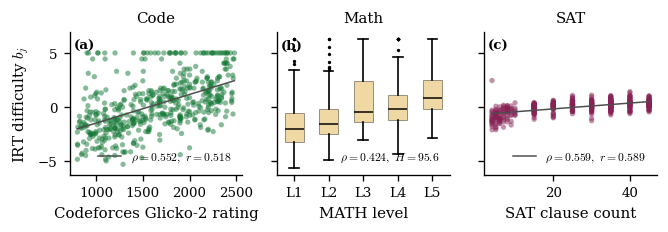

In [9]:
from scipy.stats import pearsonr, spearmanr, kruskal

df_d = pd.read_parquet(DATA / '01_difficulties.parquet')
def domain_slice(dom):
    prefix = f'{dom}_'
    sub = df_d[df_d['item_id'].str.startswith(prefix)].copy()
    sub['join_key'] = sub['item_id'].str.slice(len(prefix))
    return sub.set_index('join_key')['difficulty']

ds = Path('data/datasets')
df_code = pd.read_parquet(ds / 'selected_500.parquet').set_index('join_key')
df_math = pd.read_parquet(ds / 'selected_500_math.parquet').set_index('join_key')
df_sat = pd.read_parquet(ds / 'selected_500_sat.parquet').set_index('join_key')

# canonical per-domain hues (shared with the dissociation figure)
DOMAIN_COLOR = {'code': '#117733', 'math': '#DDAA33', 'sat': '#882255'}

def _panel_label(ax, label):
    ax.text(0.022, 0.95, label, transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left')

fig = plt.figure(figsize=(5.5, 1.8))
gs = fig.add_gridspec(1, 3, wspace=0.20, left=0.10, right=0.99, bottom=0.22, top=0.88)

# (a) Code: scatter of Glicko-2 rating vs IRT difficulty.
ax_a = fig.add_subplot(gs[0])
m = df_code.join(domain_slice('code'), how='inner').dropna(subset=['unnorm_rating', 'difficulty'])
x, y = m['unnorm_rating'].astype(float).values, m['difficulty'].astype(float).values
r, _ = pearsonr(x, y); rho, _ = spearmanr(x, y)
ax_a.scatter(x, y, s=10, alpha=0.5, color=DOMAIN_COLOR['code'], edgecolors='none')
z = np.polyfit(x, y, 1); xs = np.linspace(x.min(), x.max(), 50)
ax_a.plot(xs, np.polyval(z, xs), color='0.3', lw=0.9, label=fr'$\rho={rho:.3f},\ r={r:.3f}$')
ax_a.set_title('Code'); ax_a.set_xlabel('Codeforces Glicko-2 rating')
ax_a.set_ylabel(r'IRT difficulty $b_j$')
ax_a.legend(loc='lower right', frameon=False, labelspacing=0.15)
_panel_label(ax_a, '(a)')

# (b) Math: boxplot of IRT difficulty by MATH level.
ax_b = fig.add_subplot(gs[1], sharey=ax_a)
plt.setp(ax_b.get_yticklabels(), visible=False)
m = df_math.join(domain_slice('math'), how='inner').dropna(subset=['level_int', 'difficulty'])
m['level_int'] = m['level_int'].astype(int)
groups = [m[m['level_int'] == L]['difficulty'].values for L in range(1, 6)]
bp = ax_b.boxplot(groups, positions=range(1, 6), widths=0.55, patch_artist=True,
                  medianprops=dict(color='black', lw=0.9),
                  flierprops=dict(marker='.', markersize=2, color='0.5'))
for patch in bp['boxes']:
    patch.set_facecolor(DOMAIN_COLOR['math']); patch.set_alpha(0.45)
    patch.set_edgecolor('black'); patch.set_linewidth(0.5)
rho, _ = spearmanr(m['level_int'], m['difficulty']); H, _ = kruskal(*groups)
ax_b.set_xticks(range(1, 6)); ax_b.set_xticklabels([f'L{i}' for i in range(1, 6)])
ax_b.set_title('Math'); ax_b.set_xlabel('MATH level')
ax_b.plot([], [], ' ', label=fr'$\rho={rho:.3f},\ H={H:.1f}$')
ax_b.legend(loc='lower right', frameon=False, labelspacing=0.15, handlelength=0)
_panel_label(ax_b, '(b)')

# (c) SAT: scatter of clause count vs IRT difficulty.
ax_c = fig.add_subplot(gs[2], sharey=ax_a)
plt.setp(ax_c.get_yticklabels(), visible=False)
m = df_sat.join(domain_slice('sat'), how='inner').dropna(subset=['num_clauses', 'difficulty'])
x, y = m['num_clauses'].astype(float).values, m['difficulty'].astype(float).values
r, _ = pearsonr(x, y); rho, _ = spearmanr(x, y)
ax_c.scatter(x, y, s=10, alpha=0.5, color=DOMAIN_COLOR['sat'], edgecolors='none')
z = np.polyfit(x, y, 1); xs = np.linspace(x.min(), x.max(), 50)
ax_c.plot(xs, np.polyval(z, xs), color='0.3', lw=0.9, label=fr'$\rho={rho:.3f},\ r={r:.3f}$')
ax_c.set_title('SAT'); ax_c.set_xlabel('SAT clause count')
ax_c.legend(loc='lower right', frameon=False, labelspacing=0.15)
_panel_label(ax_c, '(c)')

fig.savefig(OUT_FIGS / 'external_validation.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'external_validation.png', dpi=300, bbox_inches='tight')
plt.show()
